# Stopping time simulations

In [62]:
# imports
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent
SRC = ROOT / "src"
sys.path.insert(0, str(SRC))

import time
import numpy as np
import matplotlib.pyplot as plt
import scipy

from helpers.sample import make_sample, stopping_time

In [63]:
theta = 0.05
N = 5000
alpha = 0.05
beta = 0.95
B = 500

stopping_times = []
for _ in range(B):
  sample = make_sample(N, theta)
  _, st = stopping_time(sample, alpha, beta)
  stopping_times.append(st)

In [64]:
average_stopping_time = np.mean(stopping_times)
print(f"Average stopping time: {average_stopping_time / N}")
print(f"Upper bound stopping time: {(scipy.stats.norm.ppf(1-alpha) + scipy.stats.norm.ppf(beta)) / (theta * np.sqrt(N))}")

Average stopping time: 0.709842
Upper bound stopping time: 0.9304697229413388


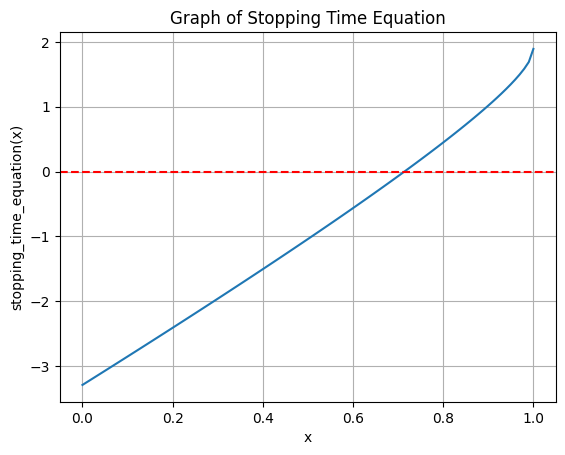

Root of stopping time equation: 0.7140262466145941


In [65]:
# set up root finding problem with equation
# equation: theta * sqrt{N} * x = z_{1-alpha} + z_beta*sqrt(1 - x)
def stopping_time_equation(x):
  return theta * np.sqrt(N) * x - (scipy.stats.norm.ppf(1-alpha) + scipy.stats.norm.ppf(beta) * np.sqrt(1 - x))

# graph function
x = np.linspace(0, 1, 100)
y = stopping_time_equation(x)
plt.plot(x, y)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('x')
plt.ylabel('stopping_time_equation(x)')
plt.title('Graph of Stopping Time Equation')
plt.grid()
plt.show()

# find root of equation
from scipy.optimize import root_scalar
result = root_scalar(stopping_time_equation, bracket=[0, 1], method='bisect')
print(f"Root of stopping time equation: {result.root}")